In [ ]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_opto-mFC_2/goalNav/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_opto-mFC_2/goalNav/code


In [ ]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)

In [15]:
# other imports
import numpy as np
from importlib import reload

## Exp. Design
Write some text about experimental design

## Performance Metrics

#### Learning
Start simple, lets look at trials across learning between conditions & in expert behaviour (when stim starts)

In [29]:
from GridMaze.analysis.behaviour import learning as bl

learning_df = bl.get_learning_curve_df()
expert_df = bl.get_expert_performance_df()

maze order: 1
Learning stats:
                  Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      total_trials
No. Observations:       135          Method:                  ML          
No. Groups:             15           Scale:                   259.5240    
Min. group size:        9            Log-Likelihood:          -582.9639   
Max. group size:        9            Converged:               Yes         
Mean group size:        9.0                                               
--------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
--------------------------------------------------------------------------
Intercept                      26.569    6.686  3.974 0.000  13.464 39.675
condition[T.opto]              -3.887    9.788 -0.397 0.691 -23.071 15.297
day_on_maze                     8.667    0.735 11.786 0.000   7.225 10.108
condition[T.op

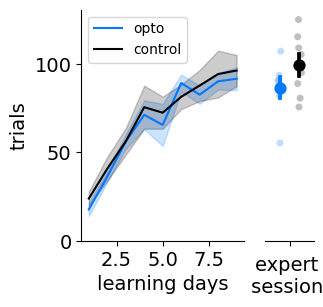

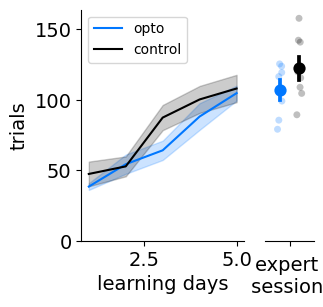

In [30]:
reload(bl)
for maze_order in [1, 2]:
    print(f"maze order: {maze_order}")
    fig, axes = plt.subplots(1, 2, figsize=(3, 3), width_ratios=[1, 0.3], sharey=True)
    bl.plot_performance_summary(learning_df, expert_df, maze_order=maze_order, print_stats=True, axes=axes)
    # fig.savefig(f"../results/figures/learning_maze_order_{maze_order}.pdf")

#### Excess steps (during expert behaviour with mFC inhibition)

In [11]:
from GridMaze.analysis.behaviour import performance_metrics as pm

performance_df = pm.get_performance_df()

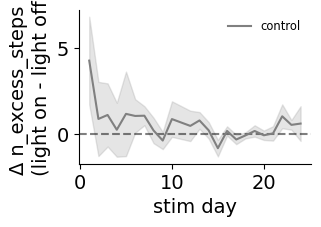

In [10]:
reload(pm)
f, ax = plt.subplots(1, 1, figsize=(3, 2))
pm.plot_stim_effects_over_days(
    performance_df,
    y="n_excess_steps",
    groups=["control"],
    rolling_avg=False,
    ax=ax,
)

Mixed ANOVA: trial_duration
+-------------+-----------+-------+-------+-----------+-----------+----------+------------+-------+
| Source      |        SS |   DF1 |   DF2 |        MS |         F |    p-unc |        np2 |   eps |
|-------------+-----------+-------+-------+-----------+-----------+----------+------------+-------|
| condition   | 28.3981   |     1 |    13 | 28.3981   | 1.45212   | 0.249666 | 0.100478   |   nan |
| stim_trial  |  0.124444 |     1 |    13 |  0.124444 | 0.0860694 | 0.773866 | 0.00657718 |     1 |
| Interaction |  1.37036  |     1 |    13 |  1.37036  | 0.947778  | 0.348053 | 0.0679519  |   nan |
+-------------+-----------+-------+-------+-----------+-----------+----------+------------+-------+
Mixed ANOVA: n_errors
+-------------+-------------+-------+-------+-------------+----------+-----------+-----------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |        F |     p-unc |       np2 |   eps |
|-------------+-------------+-------+-------

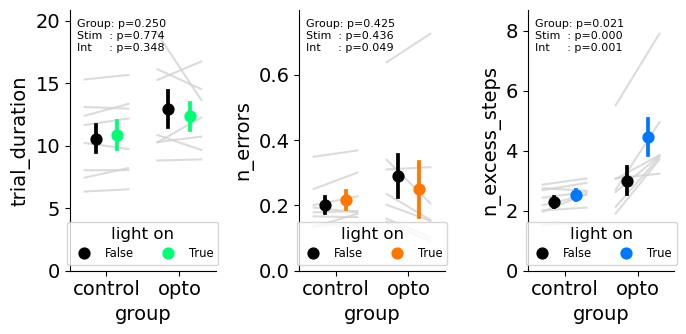

In [ ]:
reload(pm)
from GridMaze.analysis.core import plotting as cp

reload(cp)

stim_day_range = (8, np.inf)

fig, axes = plt.subplots(1, 3, figsize=(7, 3.5))
for y, ax, ot, color in zip(
    ["trial_duration", "n_errors", "n_excess_steps"],
    axes,
    [3 * 60, 15, 500],  # roughly 99.5th percentiles
    ["#00FF77", "#FF7700", "#0077FF"],
):
    pm.plot_random_effects_summary(
        performance_df,
        y=y,
        stim_day_range=stim_day_range,
        outlier_thres=ot,
        print_stats=True,
        stim_color=color,
        ax=ax,
    )
fig.tight_layout()

### Example trajectory plots

In [ ]:
from GridMaze.analysis.core import get_sessions as gs
from GridMaze.analysis.behaviour import trajectory_plotting as tp

session = gs.get_maze_sessions(subject_IDs=["mFC-opto_23"], maze_names=["maze_2"], days_on_maze=[9])[0]

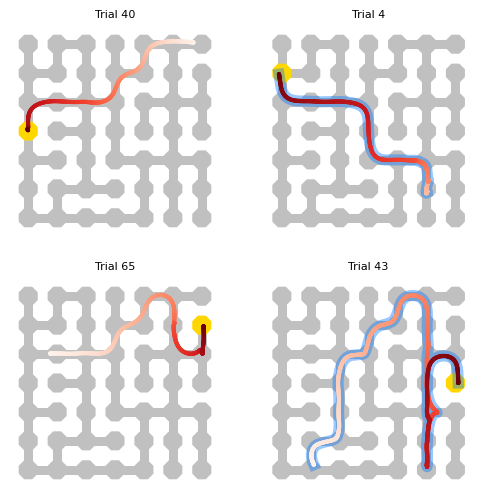

In [ ]:
f, axes = plt.subplots(2, 2, figsize=(6, 6))
for ax, t in zip(axes.flatten(), [40, 4, 65, 43]):
    tp.plot_fancy_trial_trajectory(session, trial=t, ax=ax)
f.savefig("../results/figures/opto_trajectory_examples.pdf")

In [22]:
session2 = gs.get_maze_sessions(subject_IDs=["mFC-opto_26"], total_stim_days=[17])[0]

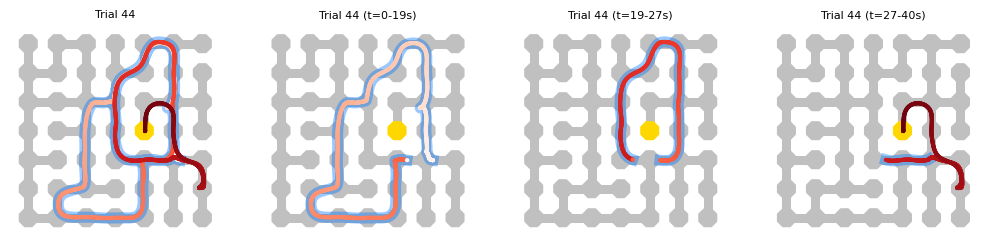

In [ ]:
# another example disrupted nav trial in opto subject
reload(tp)
trial = 44
f, axes = plt.subplots(1, 4, figsize=(12.5, 3.5))
for ax, t_range in zip(axes, [None, (0, 19), (19, 27), (27, 40)]):
    tp.plot_fancy_trial_trajectory(session2, trial=trial, t_range=t_range, ax=ax)
f.savefig("../results/figures/opto_trajectory_examples2.pdf")

### Is the group x stim effect equally strong on all trials or does it interact with maze structure / starting distance to goal, etc.

In [ ]:
# next